In [1]:
from PINN_XWave_DDP import *

/home/aleotz/Plasma_PINNS/PINN_XWave_DDP.py:348: SyntaxWarning: invalid escape sequence '\o'
  ax.set_xlabel(f'$x [\\frac{{c}}{{\omega_{{pe}}}}]$')
/home/aleotz/Plasma_PINNS/PINN_XWave_DDP.py:352: SyntaxWarning: invalid escape sequence '\p'
  if f'$\phi [\\frac{{m_{{e}}c^2}}{{e}}]$' in title:
/home/aleotz/Plasma_PINNS/PINN_XWave_DDP.py:355: SyntaxWarning: invalid escape sequence '\d'
  if f'$\dot{{B}} [\\frac{{e}}{{m_{{e}}c}}]$' in title:
/home/aleotz/Plasma_PINNS/PINN_XWave_DDP.py:383: SyntaxWarning: invalid escape sequence '\o'
  ax.set_xlabel(f'$x [\\frac{{c}}{{\omega_{{pe}}}}]$')


In [3]:
#Global variables physics constants
vth = .1
omega_ce = 2.
omega = 2.5
omega_pe = 1.0
phi_amp = 1.
B0 = 1.0  # Background magnetic field strength


k, k_lambda_D = dispersion(omega, omega_ce, omega_pe, vth)
print(f"k = {k:.3f}, k*lambda_D = {k_lambda_D:.3f}")

omega_list = [omega]
phi_amp_list = [phi_amp]  # Amplitude of the electric field
delta_list = [0.0]  # Phase factor for the wave solution
B0_list = [B0]

lamda = 2 * np.pi / k  # Wavelength
T = (2 * np.pi) / omega  # Period of the wave
xmin, xmax = 0, 3*lamda
tmin, tmax = 0, 3*T

L = xmax - xmin         # Length of the domain
tau = tmax - tmin       # Time duration of the wave
Nt = 200               # Number of time points
Nx = 200               # Number of spatial points
Nt_coll = 200           #number of collocation points in time
Nx_coll = 200           #number of collocation points in space
dt = T/float(Nt)
dx = L/float(Nx)

t_arr = np.linspace(tmin, tmax, Nt)
x_arr = np.linspace(xmin, xmax, Nx)

print(f"k = {k:.4e}")
print(f"k lambda_debye = {k_lambda_D:.4e}")
print(f"L = {L:.3e} [c / omega_pe]")
print(f"T = {T:.3e} [1 / omega_pe]")
print(f"dx = {dx:.3e} [c / omega_pe]")
print(f"dt = {dt:.3e} [1 / omega_pe]")

X_arr, T_arr, phi_flat, Bdot_flat, Ax_flat, Ay_flat, Vx_flat, Vy_flat, N_flat, B0_flat = generate_data(xmin = xmin, xmax = xmax, tmin = tmin, tmax = tmax, nx = Nx, nt = Nt, vth=vth,
                                                                                                omega_ce = omega_ce, omega_pe = omega_pe, omega_list = omega_list, phi_amp_list=phi_amp_list,
                                                                                                delta_list=delta_list)

x_sparse, t_sparse, phi_sparse, Bdot_sparse = sparse_measurements(X_arr, T_arr, phi_flat, Bdot_flat, num_samples=500)

x_coll, t_coll, dx, dt = collocation_points(xmin, xmax, tmin, tmax, Nx_coll, Nt_coll, L, tau)
print(f"Number of collocation points: {len(x_coll)}")
print(f"Number of grid points: {len(X_arr)}")

k = 1.432, k*lambda_D = 0.143
k = 1.4318e+00
k lambda_debye = 1.4318e-01
L = 1.317e+01 [c / omega_pe]
T = 2.513e+00 [1 / omega_pe]
dx = 6.583e-02 [c / omega_pe]
dt = 1.257e-02 [1 / omega_pe]
Number of collocation points: 40000
Number of grid points: 40000


In [3]:
def compare_spacing(k, omega, dx, dt):
    k_lambda_D = k * np.sqrt(1 + (omega / omega_ce)**2)
    print(f"k*lambda_D = {k_lambda_D:.4e}")
    
    # Calculate the number of wavelengths in the domain
    num_wavelengths = (xmax - xmin) / (2 * np.pi / k)
    print(f"Number of wavelengths in the domain: {num_wavelengths:.2f}")
    
    # Calculate the number of time periods in the domain
    num_periods = (tmax - tmin) / (2 * np.pi / omega)
    print(f"Number of time periods in the domain: {num_periods:.2f}")
    
    return 
compare_spacing(k, omega, dx, dt)

k*lambda_D = 2.2920e+00
Number of wavelengths in the domain: 3.00
Number of time periods in the domain: 3.00


<>:5: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1333030/3542494858.py:5: SyntaxWarning: invalid escape sequence '\p'
  titles_GT = [f'$\phi [\\frac{{m_{{e}}c^2}}{{e}}]$',
/tmp/ipykernel_1333030/3542494858.py:6: SyntaxWarning: invalid escape sequence '\d'
  f'$\dot{{B}} [\\frac{{e}}{{m_{{e}}c}}]$',


-------Plotting Ground Truth Values-------------


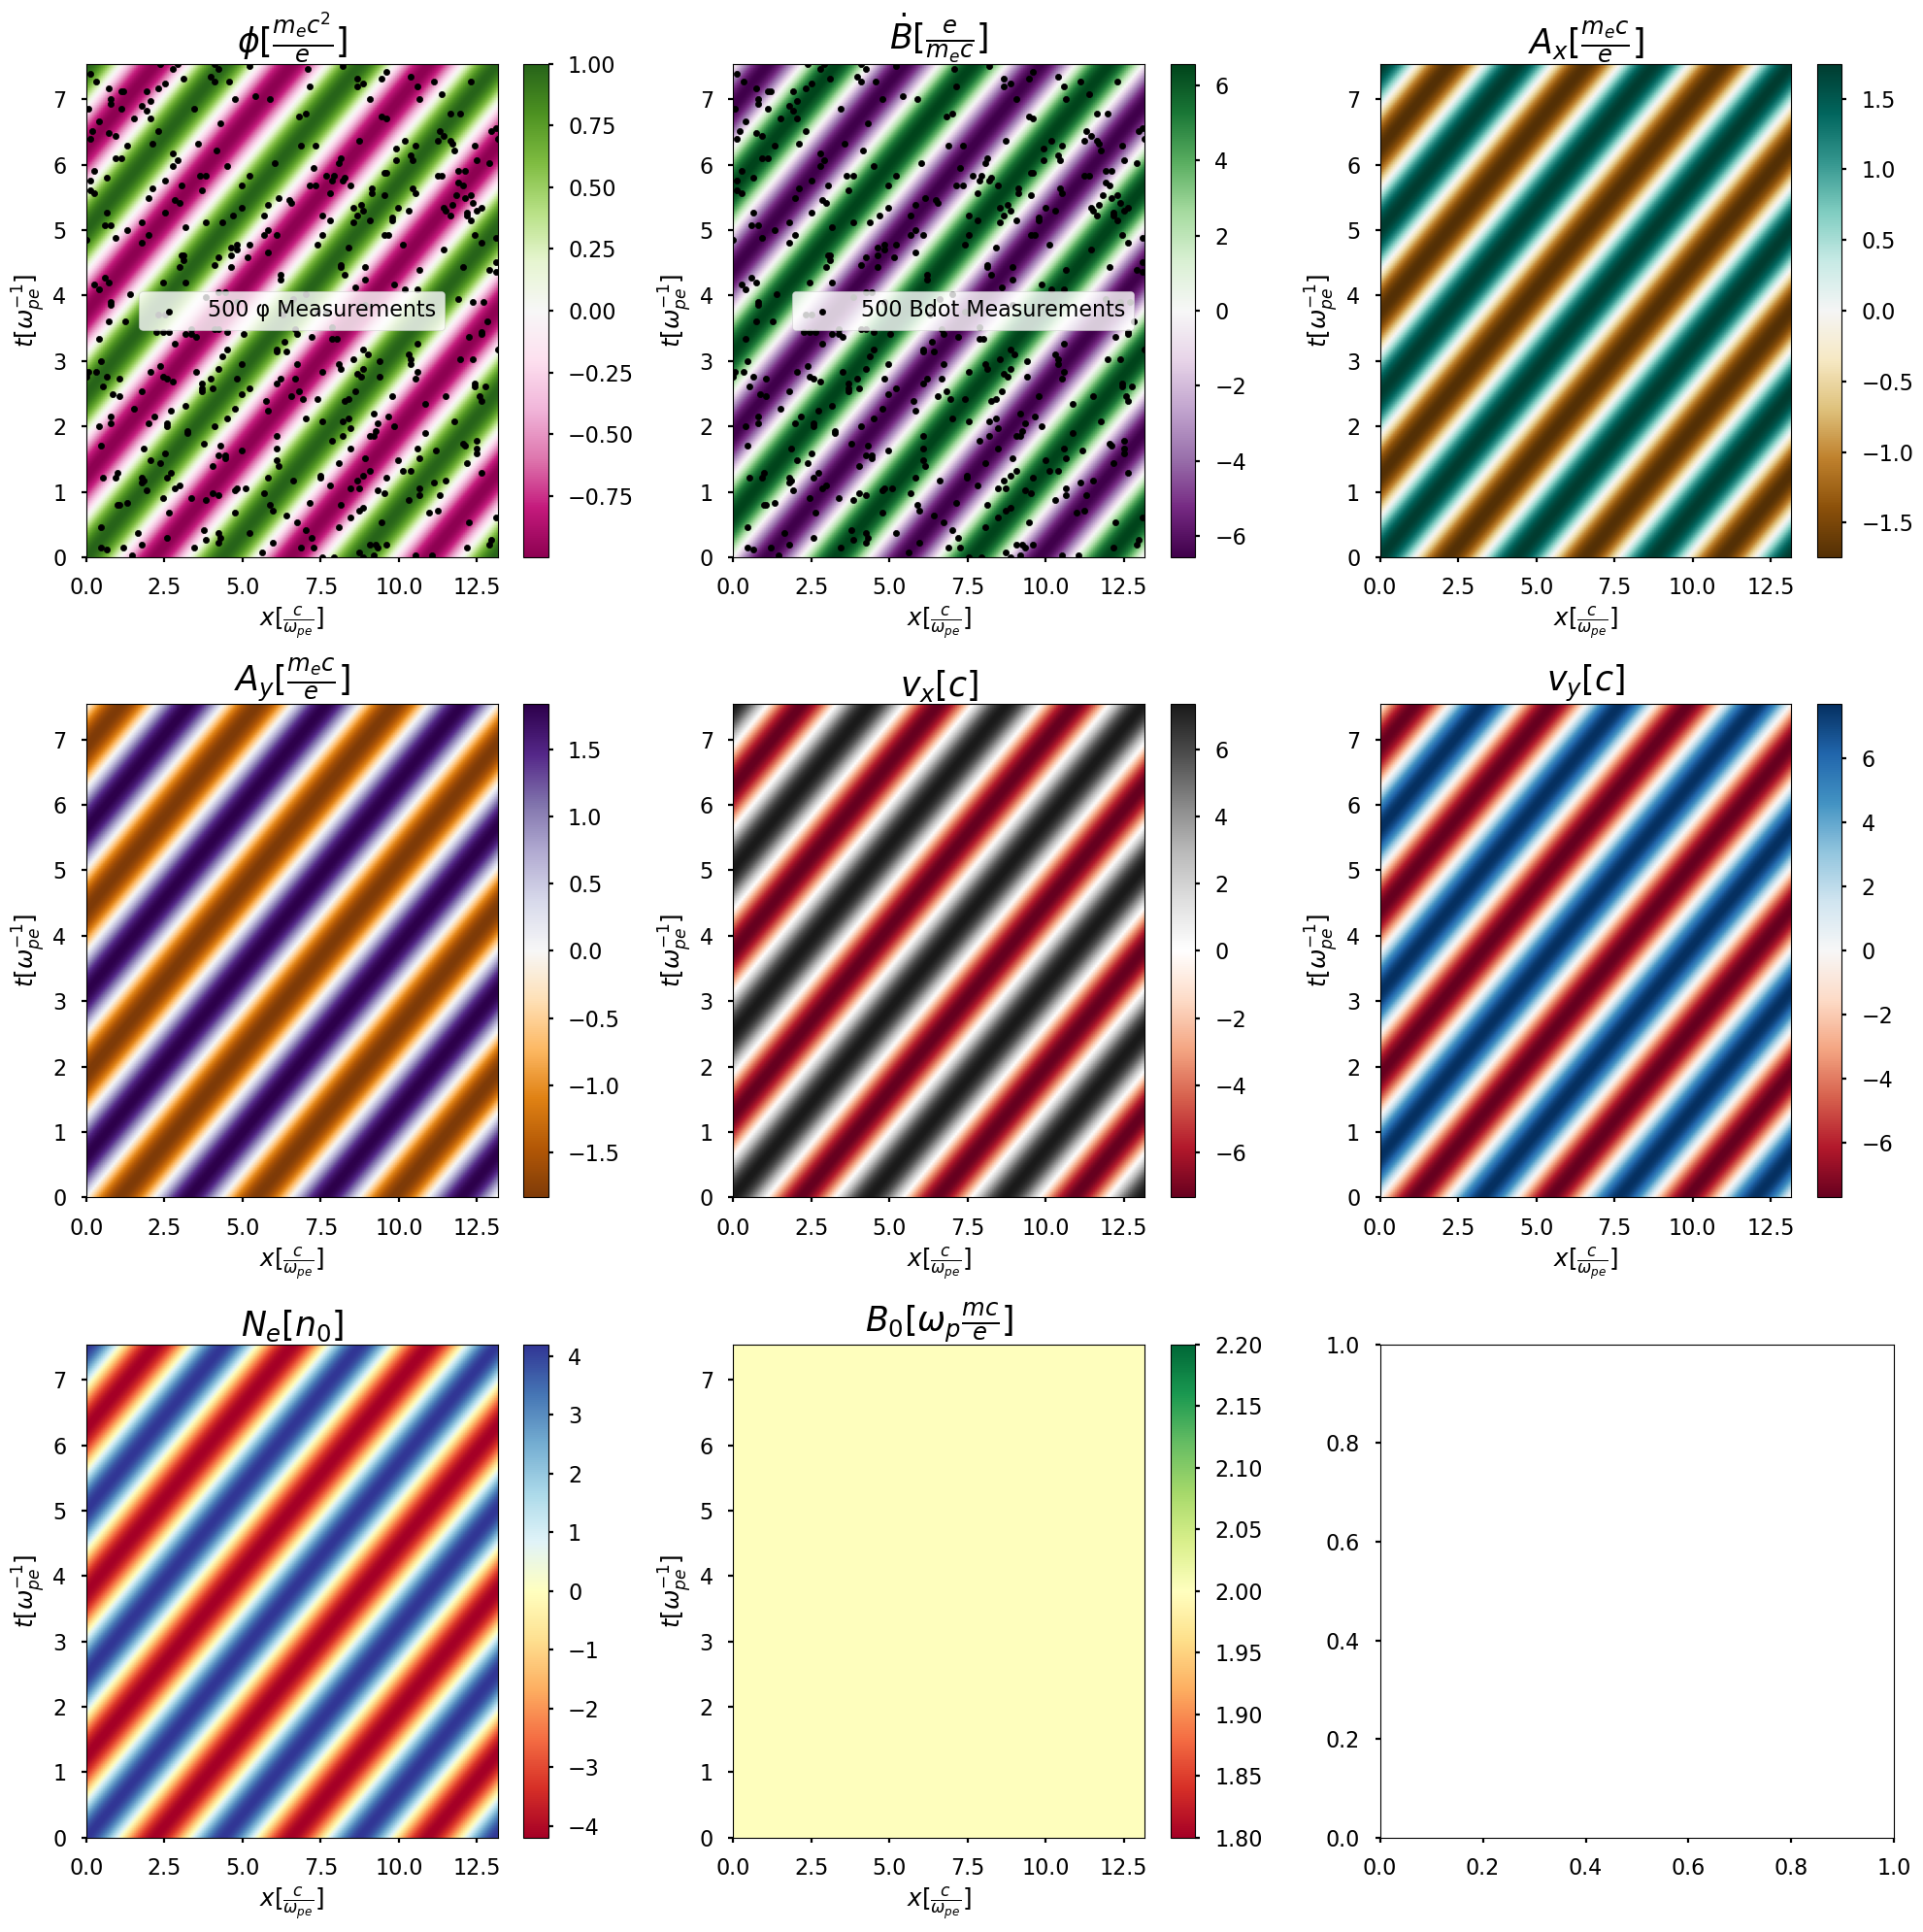

<Figure size 1280x880 with 0 Axes>

In [4]:
quantities_flat = np.real(np.array([phi_flat, Bdot_flat, Ax_flat, Ay_flat, Vx_flat, Vy_flat, N_flat, B0_flat])) #Take real part 
extent_GT = [xmin, xmax, tmin, tmax]                                    #Extent of the ground truth values
quantities_GT = [x.reshape(Nt, Nx) for x in quantities_flat]            #Reshape to 2D arrays in the shape of the collocation points
sparse = [x_sparse, t_sparse, phi_sparse, Bdot_sparse]                  #sparse phi and Bdot measurements
titles_GT = [f'$\phi [\\frac{{m_{{e}}c^2}}{{e}}]$', 
            f'$\dot{{B}} [\\frac{{e}}{{m_{{e}}c}}]$',
            f'$A_x [\\frac{{m_{{e}}c}}{{e}}]$',
            f'$A_y [\\frac{{m_{{e}}c}}{{e}}]$',
            f'$v_x [c]$', 
            f'$v_y [c]$', 
            f'$N_e [n_0]$',
            r'$B_0 [\omega_p \frac{mc}{e}]$']

#Plot Ground Truth Values
print("-------Plotting Ground Truth Values-------------")
plot_analytical(quantities=quantities_GT, sparse = sparse, titles = titles_GT, extent = extent_GT)

<>:33: SyntaxWarning: invalid escape sequence '\o'
<>:33: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_1333030/3124365926.py:33: SyntaxWarning: invalid escape sequence '\o'
  ax.set_xlabel(f'$x [\\frac{{c}}{{\omega_{{pe}}}}]$')


Adjusting title: $|\partial_t V_x - \partial_t A_{1x} - \partial_x \phi + V_y B_0|$ by subtracting mean value: 9.8037
Adjusting title: $|\partial_t V_y - \partial_t A_{1y} - V_x B_0|$ by subtracting mean value: 9.3376


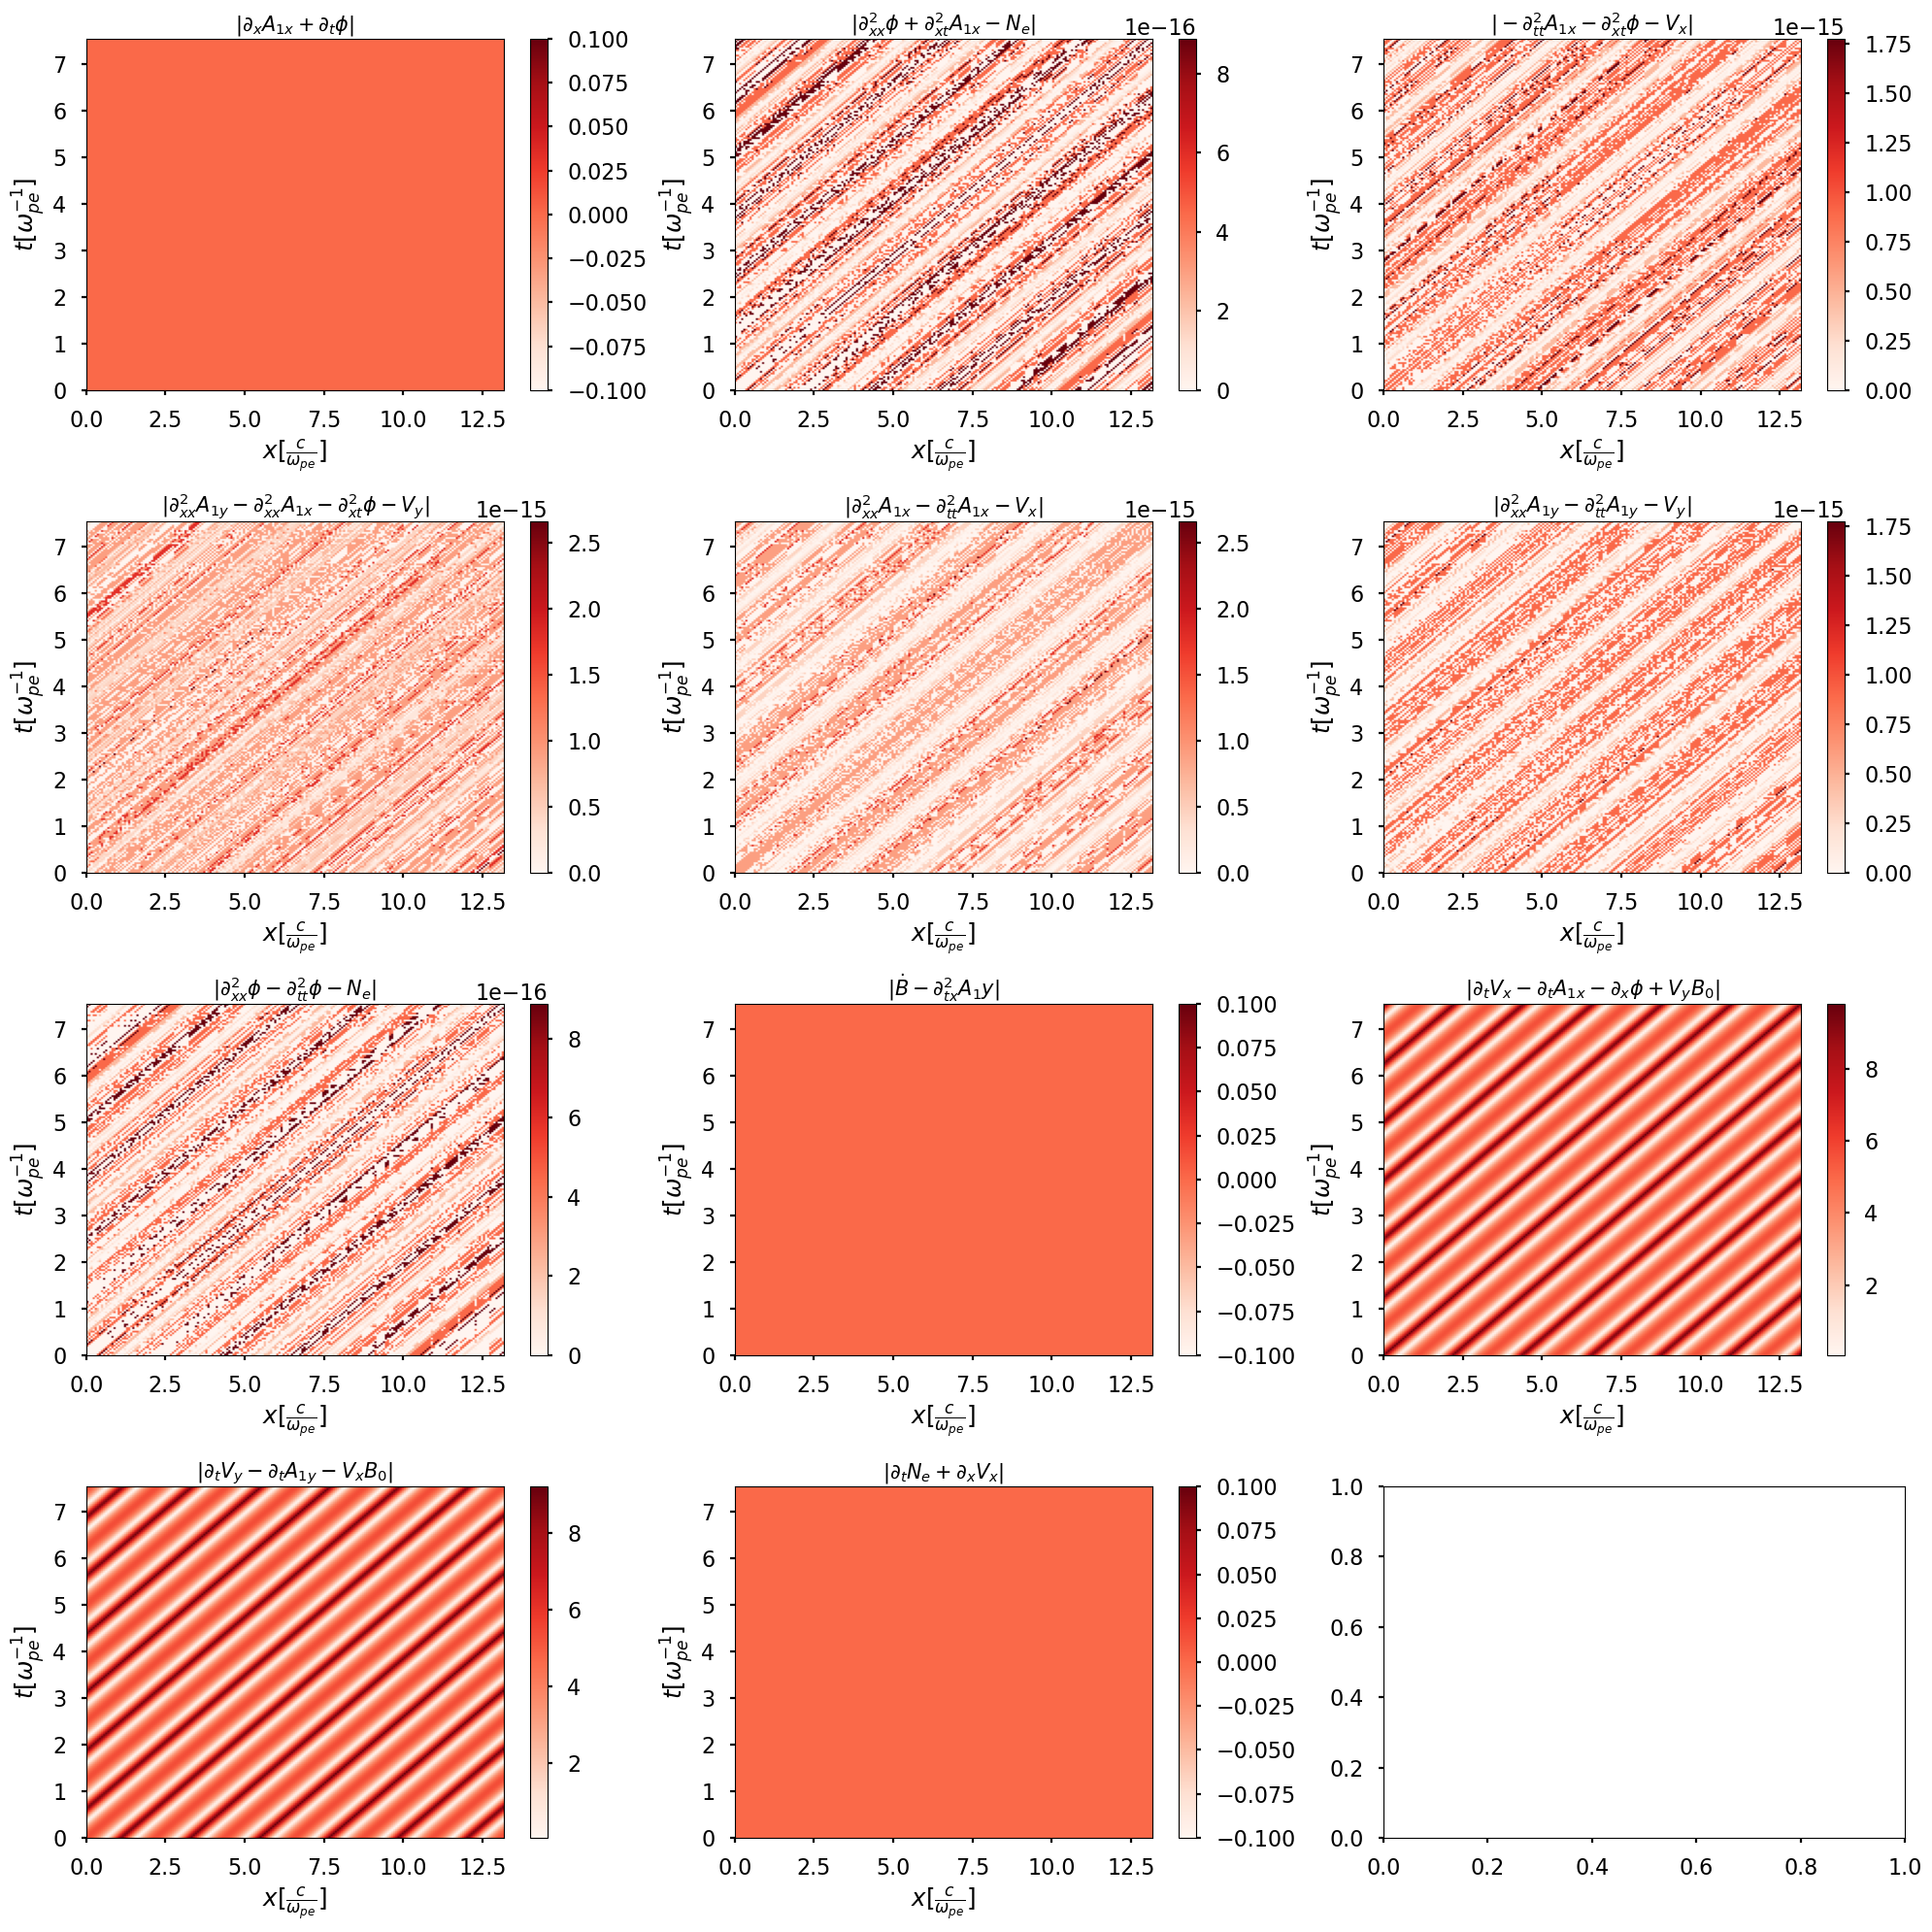

In [14]:
#Plot constraints
phi = np.real(np.array(quantities_GT[0]))
Bdot = np.real(np.array(quantities_GT[1]))
Ax = np.real(np.array(quantities_GT[2]))
Ay = np.real(np.array(quantities_GT[3]))
Vx = np.real(np.array(quantities_GT[4]))
Vy = np.real(np.array(quantities_GT[5]))
N = np.real(np.array(quantities_GT[6]))
B0 = np.real(np.array(quantities_GT[7]))

def plot_constraints(constraints, titles, extent):
    "Plots the constraints in their current form."
    fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 20))
    
    #adjusted titles to remove the average
    adjusted_titles = [r'$|\partial_t V_x - \partial_t A_{1x} - \partial_x \phi + V_y B_0|$',
                       r'$|\partial_t V_y - \partial_t A_{1y} - V_x B_0|$']
    
    for ax, constraint, title in zip(axes.flatten(), constraints, titles):
        
        #make a copy to avoid modifying the original constraint
        plot_data = np.abs(constraint.copy())
        
        if title in adjusted_titles:
            mean_value = np.mean(np.abs(plot_data))
            plot_data -= mean_value  # Remove the mean value from the constraint
            plot_data = np.abs(plot_data)  # Ensure we are plotting the absolute value
            print(f"Adjusting title: {title} by subtracting mean value: {mean_value:.4f}")
        
            
        im = ax.imshow(plot_data, aspect='auto', extent=extent, origin='lower', cmap='Reds')
        ax.set_title(title, fontsize = 15)
        ax.set_xlabel(f'$x [\\frac{{c}}{{\omega_{{pe}}}}]$')
        ax.set_ylabel('$t [\\omega_{{pe}}^{{-1}}]$')
        fig.colorbar(im, ax=ax)
        
    
    plt.tight_layout()
    plt.show()

def spectral_derivatives_2d(f, t, x, deriv_type='x', filter_factor = .5):
    """
    Computes a partial derivative of a 2D function f(t, x) using the spectral method.

    Args:
        f (np.ndarray): A 2D numpy array representing the function f(t, x).
                        The first dimension is time, the second is space.
        t (np.ndarray): 1D array of time points.
        x (np.ndarray): 1D array of spatial points.
        deriv_type (str): The type of derivative to compute ('t', 'x', 'tt', 'xx', 'xt').

    Returns:
        np.ndarray: A 2D array containing the computed partial derivative.
    """
    Nt, Nx = f.shape
    dt = t[1] - t[0]
    dx = x[1] - x[0]

    # Perform 2D FFT to move to the frequency domain
    f_hat = np.fft.fft2(f)

    # Generate wave number arrays for time (omega) and space (k)
    omega = 2 * np.pi * np.fft.fftfreq(Nt, d=dt)
    k = 2 * np.pi * np.fft.fftfreq(Nx, d=dx)
    omega_grid, k_grid = np.meshgrid(omega, k, indexing='ij')

    # Add filtering to remove high-frequency noise
    f_hat_filtered = np.zeros_like(f_hat)
    num_to_keep_t = int(Nt * filter_factor)
    num_to_keep_x = int(Nx * filter_factor)

    # Filter by keeping only the central low-frequency modes
    f_hat_filtered[0:num_to_keep_t//2, 0:num_to_keep_x//2] = f_hat[0:num_to_keep_t//2, 0:num_to_keep_x//2]
    f_hat_filtered[-num_to_keep_t//2:, 0:num_to_keep_x//2] = f_hat[-num_to_keep_t//2:, 0:num_to_keep_x//2]
    f_hat_filtered[0:num_to_keep_t//2, -num_to_keep_x//2:] = f_hat[0:num_to_keep_t//2, -num_to_keep_x//2:]
    f_hat_filtered[-num_to_keep_t//2:, -num_to_keep_x//2:] = f_hat[-num_to_keep_t//2:, -num_to_keep_x//2:]


    # Apply the appropriate differentiation rule in the frequency domain
    if deriv_type == 'x':
        deriv_hat = 1j * k_grid * f_hat
    elif deriv_type == 't':
        deriv_hat = 1j * omega_grid * f_hat
    elif deriv_type == 'xx':
        deriv_hat = -(k_grid**2) * f_hat
    elif deriv_type == 'tt':
        deriv_hat = -(omega_grid**2) * f_hat
    elif deriv_type == 'xt':
        deriv_hat = -(omega_grid * k_grid) * f_hat
    else:
        raise ValueError("Invalid derivative type. Choose from 'x', 't', 'xx', 'tt', 'xt'.")

    # Perform 2D inverse FFT to return to the spatial domain
    deriv = np.fft.ifft2(deriv_hat)

    return deriv.real

def analytical_derivative(f, deriv_type = 'x'):
    """Computes the analytical derivative of a wave function f(t, x) based on the wave equation.
    f is of the form f(t, x) ~exp(i(k*x - omega*t + delta))"""
    temp = f
    if deriv_type == 'x':
        temp = 1j*k * temp  
    elif deriv_type == 't':
        temp = -1j*omega * temp
    elif deriv_type == 'xx':
        temp = -(k**2) * temp
    elif deriv_type == 'tt':
        temp = -(omega**2) * temp
    elif deriv_type == 'xt':
        temp = omega*k * temp
    
    return np.real(temp)

#spatial derivatives use 1 and temporal use 0
# phi_x = np.gradient(phi, dx, axis=1, edge_order = 2) 
# phi_xx = np.gradient(phi_x, dx, axis=1, edge_order = 2) 
# phi_t = np.gradient(phi, dt, axis=0, edge_order = 2) 
# phi_tt = np.gradient(phi_t, dt, axis=0, edge_order = 2) 
# phi_xt = np.gradient(phi_x, dt, axis=0, edge_order = 2)

# Ax_x = np.gradient(Ax, dx, axis=1, edge_order = 2)
# Ax_xx = np.gradient(Ax_x, dx, axis=1, edge_order = 2) 
# Ax_t = np.gradient(Ax, dt, axis=0, edge_order = 2)
# Ax_tt = np.gradient(Ax_t, dt, axis=0, edge_order = 2)
# Ax_xt = np.gradient(Ax_x, dt, axis=0, edge_order = 2) 
# Ay_x = np.gradient(Ay, dx, axis=1, edge_order = 2) 
# Ay_xx = np.gradient(Ay_x, dx, axis=1, edge_order = 2) 
# Ay_t = np.gradient(Ay, dt, axis=0, edge_order = 2)
# Ay_tt = np.gradient(Ay_t, dt, axis=0, edge_order = 2) 
# Ay_xt = np.gradient(Ay_x, dt, axis=0, edge_order = 2)

# Vx_x = np.gradient(Vx, dx, axis=1, edge_order = 2) 
# Vx_t = np.gradient(Vx, dt, axis=0, edge_order = 2)
# Vy_x = np.gradient(Vy, dx, axis=1, edge_order = 2)
# Vy_t = np.gradient(Vy, dt, axis=0, edge_order = 2) 

# N_t = np.gradient(N, dt, axis=0, edge_order = 2)

#Finite Difference derivatives
# phi_x = derivative_x(phi, dx)
# phi_xx = derivative_xx(phi, dx)
# phi_t = derivative_t(phi, dt)
# phi_tt = derivative_tt(phi, dt)
# phi_xt = derivative_xt(phi, dx=dx, dt=dt)

# Ax_x = derivative_x(Ax, dx)
# Ax_xx = derivative_xx(Ax, dx)
# Ax_t = derivative_t(Ax, dt)
# Ax_tt = derivative_tt(Ax, dt)
# Ax_xt = derivative_xt(Ax, dx=dx, dt=dt)
# Ay_x = derivative_x(Ay, dx)
# Ay_xx = derivative_xx(Ay, dx)
# Ay_t = derivative_t(Ay, dt)
# Ay_tt = derivative_tt(Ay_t, dt)
# Ay_xt = derivative_xt(Ay, dx=dx, dt=dt)

# Vx_x = derivative_x(Vx, dx)
# Vx_t = derivative_t(Vx, dt)
# Vy_x = derivative_x(Vy, dx)
# Vy_t = derivative_t(Vy, dt)

# N_t = derivative_t(N, dt)

#Spectral derivatives
# phi_x = spectral_derivatives_2d(phi, x_arr, t_arr, deriv_type='x')
# phi_xx = spectral_derivatives_2d(phi, x_arr, t_arr, deriv_type='xx')
# phi_t = spectral_derivatives_2d(phi, x_arr, t_arr, deriv_type='t')
# phi_tt = spectral_derivatives_2d(phi, x_arr, t_arr, deriv_type='tt')
# phi_xt = spectral_derivatives_2d(phi, x_arr, t_arr, deriv_type='xt')

# Ax_x = spectral_derivatives_2d(Ax, x_arr, t_arr, deriv_type='x')
# Ax_xx = spectral_derivatives_2d(Ax, x_arr, t_arr, deriv_type='xx')
# Ax_t = spectral_derivatives_2d(Ax, x_arr, t_arr, deriv_type='t')
# Ax_tt = spectral_derivatives_2d(Ax, x_arr, t_arr, deriv_type='tt')
# Ax_xt = spectral_derivatives_2d(Ax, x_arr, t_arr, deriv_type='xt')
# Ay_x = spectral_derivatives_2d(Ay, x_arr, t_arr, deriv_type='x')
# Ay_xx = spectral_derivatives_2d(Ay, x_arr, t_arr, deriv_type='xx')
# Ay_t = spectral_derivatives_2d(Ay, x_arr, t_arr, deriv_type='t')
# Ay_tt = spectral_derivatives_2d(Ay, x_arr, t_arr, deriv_type='tt')
# Ay_xt = spectral_derivatives_2d(Ay, x_arr, t_arr, deriv_type='xt')

# Vx_x = spectral_derivatives_2d(Vx, x_arr, t_arr, deriv_type='x')
# Vx_t = spectral_derivatives_2d(Vx, x_arr, t_arr, deriv_type='t')
# Vy_x = spectral_derivatives_2d(Vy, x_arr, t_arr, deriv_type='x')
# Vy_t = spectral_derivatives_2d(Vy, x_arr, t_arr, deriv_type='t')

# N_t = spectral_derivatives_2d(N, x_arr, t_arr, deriv_type='t')

# phi_x = spectral_derivatives_2d(phi, x_arr, t_arr, deriv_type='x')
# phi_xx = spectral_derivatives_2d(phi, x_arr, t_arr, deriv_type='xx')
# phi_t = spectral_derivatives_2d(phi, x_arr, t_arr, deriv_type='t')
# phi_tt = spectral_derivatives_2d(phi, x_arr, t_arr, deriv_type='tt')
# phi_xt = spectral_derivatives_2d(phi, x_arr, t_arr, deriv_type='xt')


#Analytical Derivatives
phi_x_analytical = analytical_derivative(phi, deriv_type='x')
phi_xx_analytical = analytical_derivative(phi, deriv_type='xx')
phi_t_analytical = analytical_derivative(phi, deriv_type='t')
phi_tt_analytical = analytical_derivative(phi, deriv_type='tt')
phi_xt_analytical = analytical_derivative(phi, deriv_type='xt')

Ax_x_analytical = analytical_derivative(Ax, deriv_type='x')
Ax_xx_analytical = analytical_derivative(Ax, deriv_type='xx')
Ax_t_analytical = analytical_derivative(Ax, deriv_type='t')
Ax_tt_analytical = analytical_derivative(Ax, deriv_type='tt')
Ax_xt_analytical = analytical_derivative(Ax, deriv_type='xt')
Ay_x_analytical = analytical_derivative(Ay, deriv_type='x')
Ay_xx_analytical = analytical_derivative(Ay, deriv_type='xx')
Ay_t_analytical = analytical_derivative(Ay, deriv_type='t')
Ay_tt_analytical = analytical_derivative(Ay, deriv_type='tt')
Ay_xt_analytical = analytical_derivative(Ay, deriv_type='xt')

Vx_x_analytical = analytical_derivative(Vx, deriv_type='x')
Vx_t_analytical = analytical_derivative(Vx, deriv_type='t')
Vy_x_analytical = analytical_derivative(Vy, deriv_type='x')
Vy_t_analytical = analytical_derivative(Vy, deriv_type='t')

N_t_analytical = analytical_derivative(N, deriv_type='t')


#Constraints
# gauge = Ax_x + phi_t                                #Gauge
# maxwell_den = phi_xx + Ax_xt - N                    #Maxwell_den
# maxwell_cur_x = -Ax_tt - phi_xt - Vx                #Maxwell_cur_x
# maxwell_cur_y = Ay_xx - Ay_tt - Ax_xx - phi_xt - Vy #Maxwell_cur_y
# wave_Ax = Ax_xx - Ax_tt - Vx                        #Wave equation for Ax
# wave_Ay = Ay_xx - Ay_tt - Vy                        #Wave equation for Ay
# wave_phi = phi_xx - phi_tt - N                      #Wave equation for phi
# bdot_curlA = Bdot - Ay_xt                           #time derivative of definition of A
# momentum_x = Vx_t - Ax_t - phi_x + Vy*(.5*B0 + Ay_x) #momentum x direction (PROBLEM)
# momentum_y = Vy_t - Ay_t - Vx*(.5*B0 + Ay_x)        #momentum y direction (PROBLEM)
# continuity = N_t + Vx_x                             #continuity

gauge = Ax_x_analytical + phi_t_analytical                                                      #Gauge
maxwell_den = phi_xx_analytical + Ax_xt_analytical - N                                          #Maxwell_den
maxwell_cur_x = -Ax_tt_analytical - phi_xt_analytical - Vx                                      #Maxwell_cur_x
maxwell_cur_y = Ay_xx_analytical - Ay_tt_analytical - Ax_xx_analytical - phi_xt_analytical - Vy #Maxwell_cur_y
wave_Ax = Ax_xx_analytical - Ax_tt_analytical - Vx                                              #Wave equation for Ax
wave_Ay = Ay_xx_analytical - Ay_tt_analytical - Vy                                              #Wave equation for Ay
wave_phi = phi_xx_analytical - phi_tt_analytical - N                                            #Wave equation for phi
bdot_curlA = Bdot - Ay_xt_analytical                                                            #time derivative of definition of A
momentum_x = Vx_t_analytical - Ax_t_analytical - phi_x_analytical + Vy*B0 #momentum x direction
momentum_y = Vy_t_analytical - Ay_t_analytical - Vx*B0                  #momentum y direction
continuity = N_t_analytical + Vx_x_analytical                                                   #continuity



constraints = [gauge, maxwell_den, maxwell_cur_x, maxwell_cur_y,
               wave_Ax, wave_Ay, wave_phi, bdot_curlA,
               momentum_x, momentum_y, continuity]
constraint_titles = [r'$|\partial_x A_{1x} + \partial_t \phi|$', #gauge
          r'$|\partial_{xx}^2 \phi + \partial_{xt}^2 A_{1x} - N_e|$', #maxwell_den
          r'$|-\partial_{tt}^2 A_{1x} - \partial_{xt}^2 \phi - V_x|$', #maxwell_cur_x
          r'$|\partial_{xx}^2 A_{1y} - \partial_{xx}^2 A_{1x} - \partial_{xt}^2 \phi - V_y|$', #maxwell_cur_y
          r'$|\partial_{xx}^2 A_{1x} - \partial_{tt}^2 A_{1x} - V_x|$',                 #wave equation for Ax   
          r'$|\partial_{xx}^2 A_{1y} - \partial_{tt}^2 A_{1y} - V_y|$',         #wave equation for Ay
          r'$|\partial_{xx}^2 \phi - \partial_{tt}^2 \phi - N_e|$',              #wave equation for phi
          r'$|\dot{B} - \partial_{tx}^2 A_1y|$',                                #Time derivative of definition of A
          r'$|\partial_t V_x - \partial_t A_{1x} - \partial_x \phi + V_y B_0|$', #momentum x direction
          r'$|\partial_t V_y - \partial_t A_{1y} - V_x B_0|$',                   #momentum y direction
          r'$|\partial_t N_e + \partial_x V_x|$']                                 #continuity
# constraint_titles = list(np.linspace(1,11,11))
plot_constraints(constraints=constraints, titles=constraint_titles, extent = extent_GT)

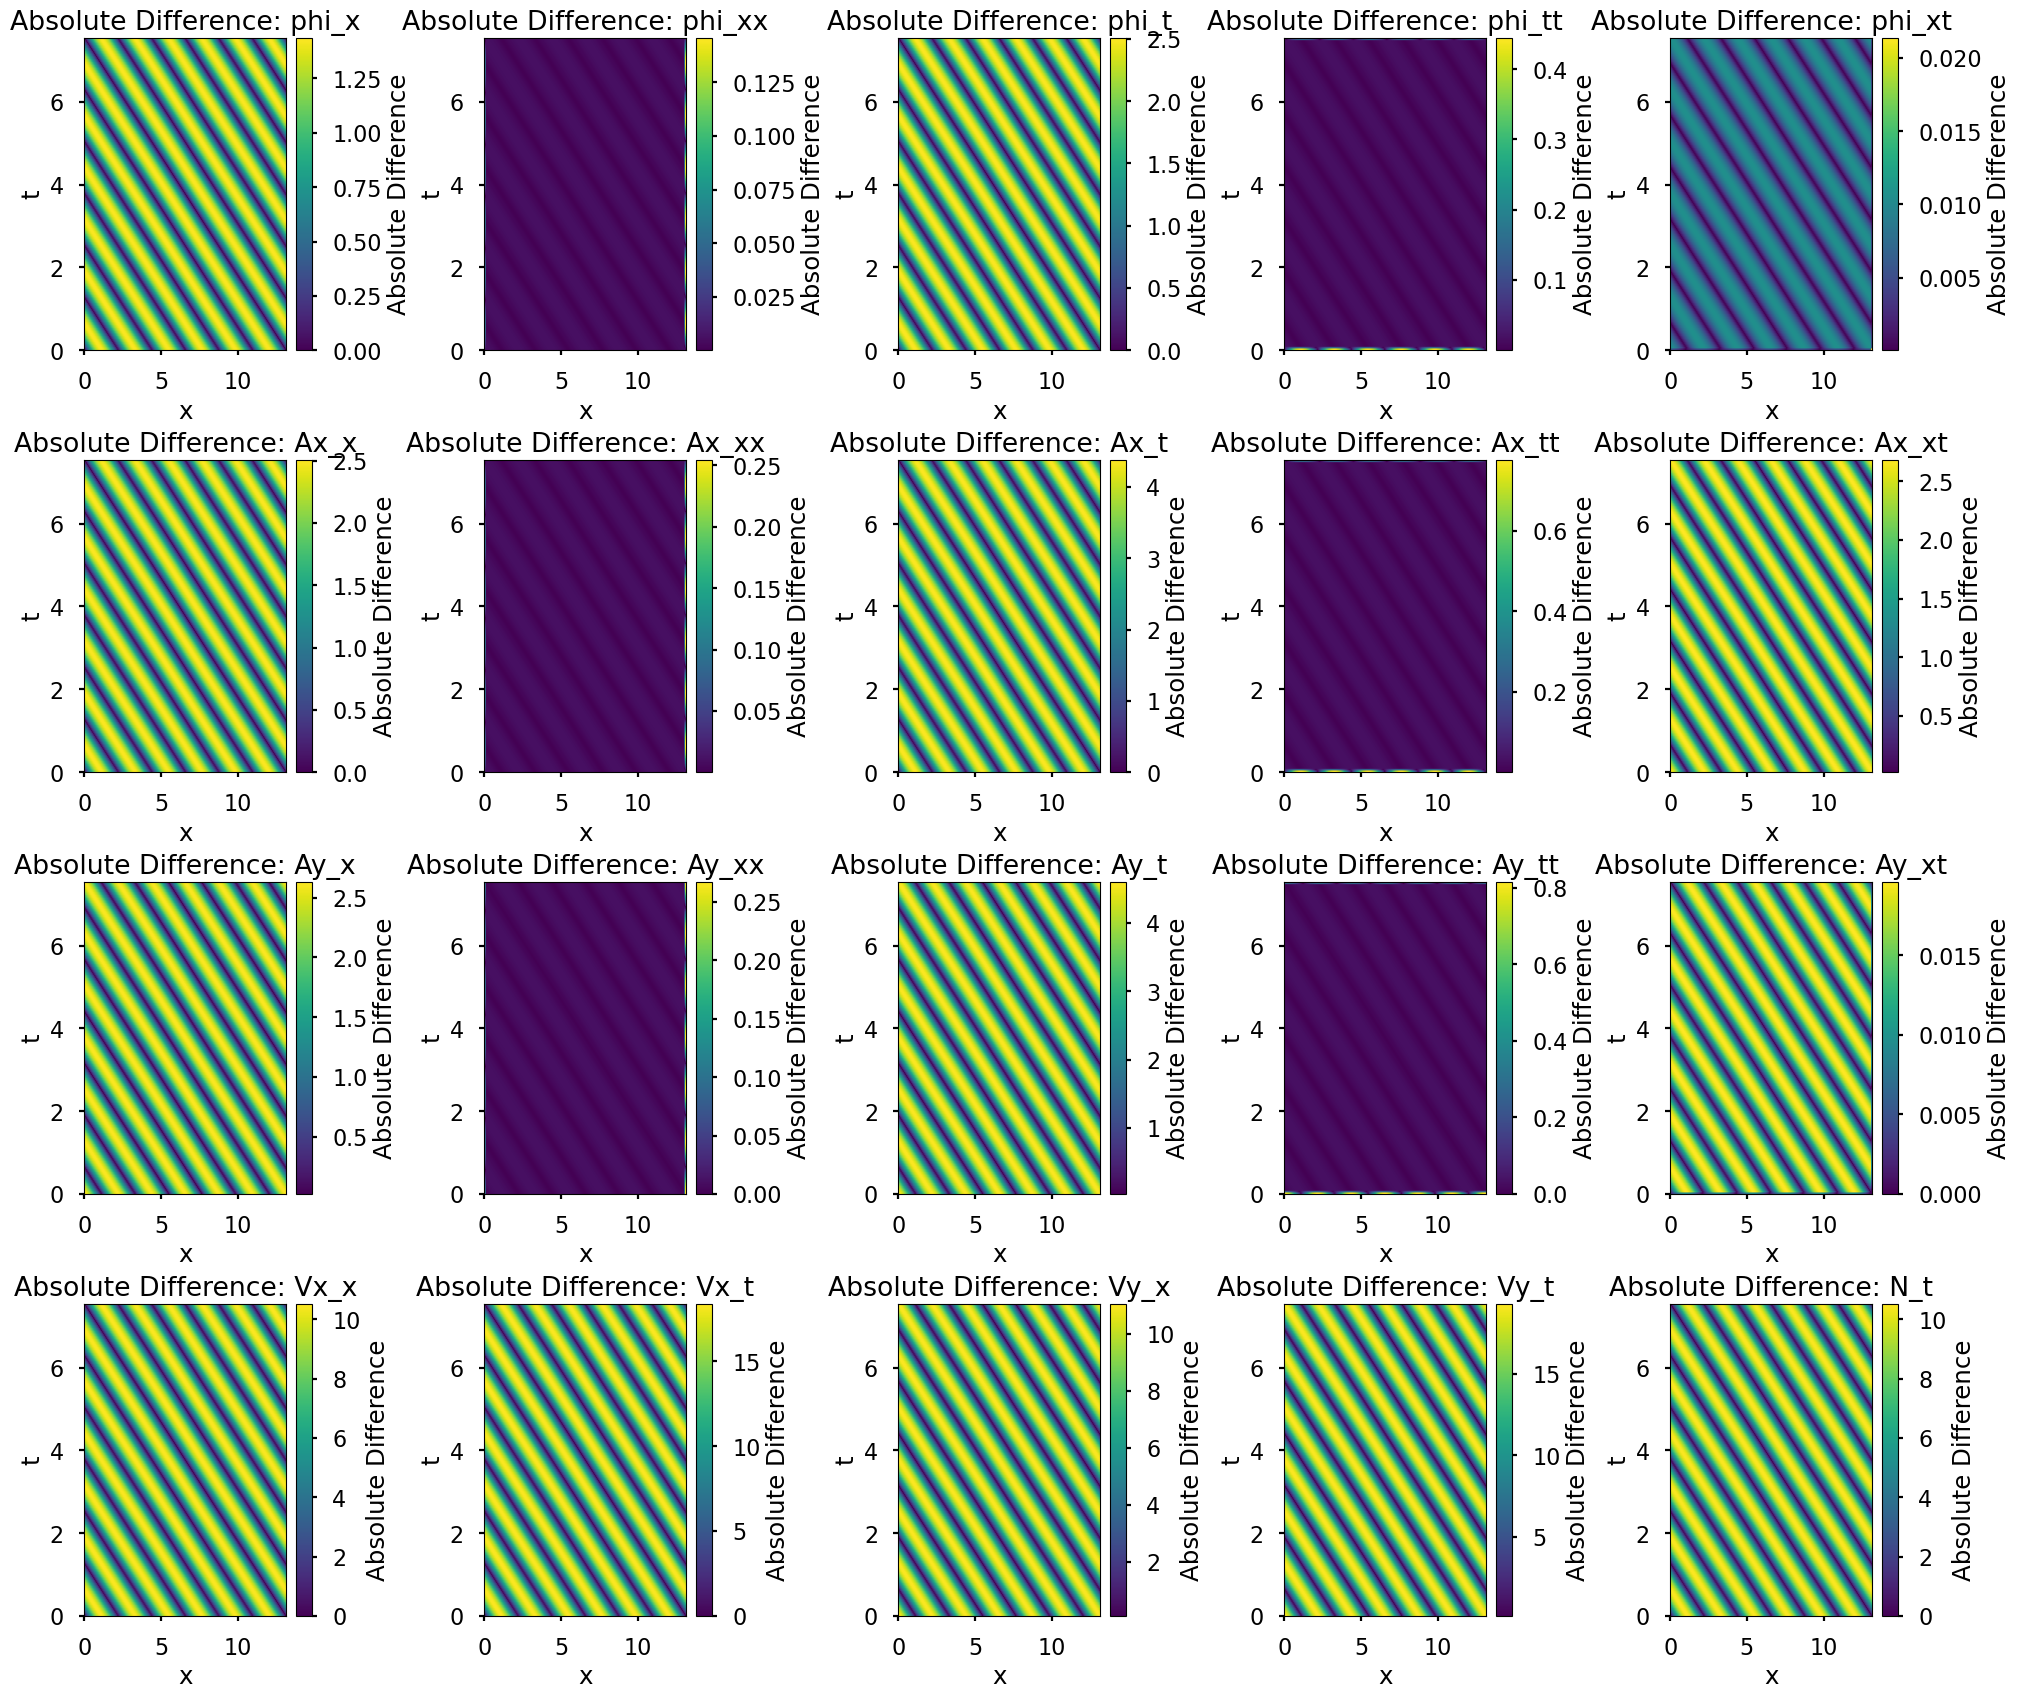

In [15]:
# phi = quantities_GT[0]
# Bdot= quantities_GT[1]
# Ax = quantities_GT[2]
# Ay = quantities_GT[3]
# Vx = quantities_GT[4]
# Vy = quantities_GT[5]
# N = quantities_GT[6]


# #Numerical Derivatives
phi_x = derivative_x(phi, dx)
phi_xx = derivative_x(phi_x, dx)
phi_t = derivative_t(phi, dt)
phi_tt = derivative_t(phi_t, dt)
phi_xt = derivative_t(phi_x, dt)

Ax_x = derivative_x(Ax, dx)
Ax_xx = derivative_x(Ax_x, dx)
Ax_t = derivative_t(Ax, dt)
Ax_tt = derivative_t(Ax_t, dt)
Ax_xt = derivative_t(Ax_x, dx)
Ay_x = derivative_x(Ay, dx)
Ay_xx = derivative_x(Ay_x, dx)
Ay_t = derivative_t(Ay, dt)
Ay_tt = derivative_t(Ay_t, dt)
Ay_xt = derivative_t(Ay_x, dt)

Vx_x = derivative_x(Vx, dx)
Vx_t = derivative_t(Vx, dt)
Vy_x = derivative_x(Vy, dx)
Vy_t = derivative_t(Vy, dt)

N_t = derivative_t(N, dt)

num_sols = [phi_x, phi_xx, phi_t, phi_tt, phi_xt,
            Ax_x, Ax_xx, Ax_t, Ax_tt, Ax_xt,
            Ay_x, Ay_xx, Ay_t, Ay_tt, Ay_xt,
            Vx_x, Vx_t, Vy_x, Vy_t, N_t]

N_t_analytical = -1j*omega*N

analytical_sols = np.real(np.array([phi_x_analytical, phi_xx_analytical, phi_t_analytical, phi_tt_analytical, phi_xt_analytical,
            Ax_x_analytical, Ax_xx_analytical, Ax_t_analytical, Ax_tt_analytical, Ax_xt_analytical,
            Ay_x_analytical, Ay_xx_analytical, Ay_t_analytical, Ay_tt_analytical, Ay_xt_analytical,
            Vx_x_analytical, Vx_t_analytical, Vy_x_analytical, Vy_t_analytical, N_t_analytical]))

titles_sols = ['phi_x', 'phi_xx', 'phi_t', 'phi_tt', 'phi_xt',
               'Ax_x', 'Ax_xx', 'Ax_t', 'Ax_tt', 'Ax_xt',
               'Ay_x', 'Ay_xx', 'Ay_t', 'Ay_tt', 'Ay_xt',
               'Vx_x', 'Vx_t', 'Vy_x', 'Vy_t', 'N_t']
def compare_derives(analytical_sols, num_sols, titles, extent):
    # This creates a 5x4 grid, so axs is a 2D NumPy array of Axes objects.
    # I've changed it to 2x2 to match the mock data.
     # Create a 5x5 grid to accommodate all 21 derivatives
    fig, axs = plt.subplots(5, 5, figsize=(20, 20), constrained_layout=True)

    # Flatten the axes array to easily iterate
    axs = axs.flatten()

    for i, (analytical, numerical, title) in enumerate(zip(analytical_sols, num_sols, titles)):
        if i < len(axs):
            ax = axs[i]
            # Calculate the absolute difference between the solutions
            difference = np.abs(analytical - numerical)
            epsilon=1e-12
            rel_error = difference/(np.abs(analytical)+epsilon)
            percent_accuracy = (1-rel_error)*100
            mean_accuracy = np.mean(percent_accuracy)

            # Plot the difference using imshow
            im = ax.imshow(np.abs(difference), extent=extent, aspect='auto')
            fig.colorbar(im, ax=ax, label='Absolute Difference')

            ax.set_title(f'Absolute Difference: {title}')
            ax.set_xlabel('x')
            ax.set_ylabel('t')

    # Hide any unused subplots
    for j in range(len(analytical_sols), len(axs)):
        fig.delaxes(axs[j])


    plt.show()
compare_derives(analytical_sols, num_sols, titles=titles_sols, extent=extent_GT)

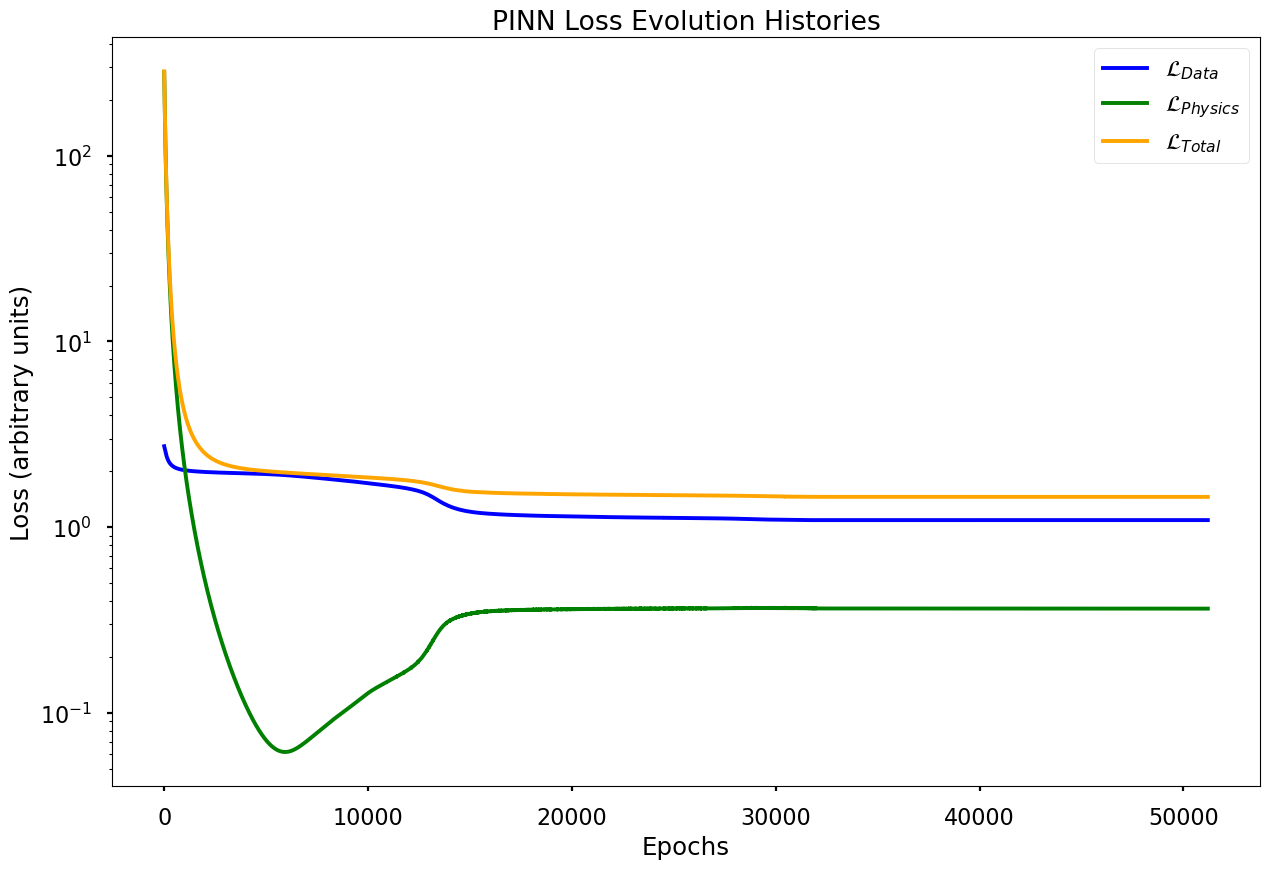

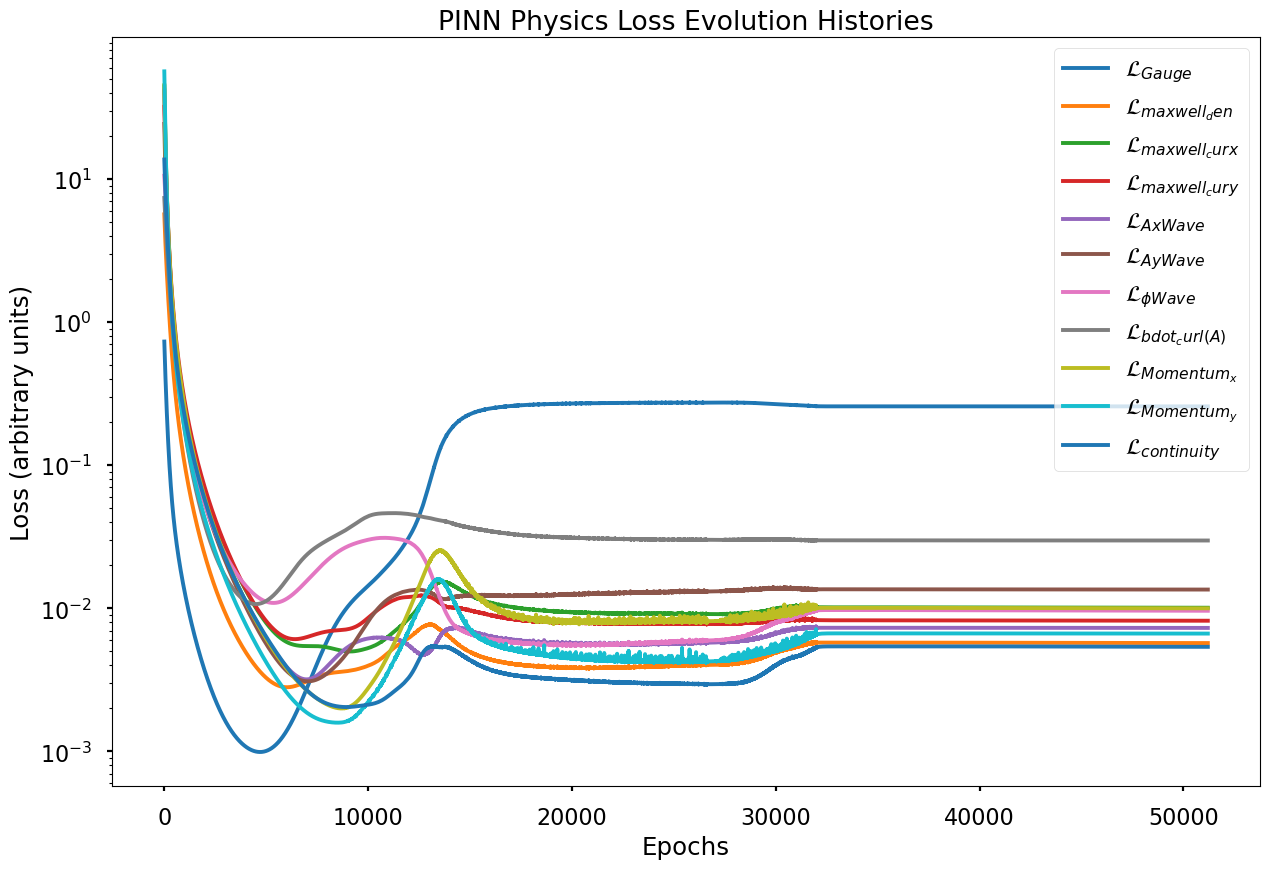

In [9]:
import pickle
from PINN_XWave_DDP import plot_loss_histories
from PINN_XWave_DDP import MLP
import torch
with open('ddp_xwave_hist.pkl', 'rb') as f:
    history = pickle.load(f)

plot_loss_histories(history)

Validating the Model

In [10]:
from PINN_XWave_DDP import *

# Load the model
vth = 0.1
omega_ce = 2.0
omega_pe = 1.0
k_init, _ = dispersion(2.5, omega_ce, omega_pe, vth)
lamda_wave_init = 2 * np.pi / k_init
T_wave_init = (2 * np.pi) / 2.5
xmin_init, xmax_init = 0, 3 * lamda_wave_init
tmin_init, tmax_init = 0, 3 * T_wave_init

model_params = {
    'extent': np.array([tmin_init, tmax_init, xmin_init, xmax_init]),
    'num_hidden_layers': 3,
    'hidden_size': 30,
    'activation': 'sin',
    'init': 'xavier',
    'input_encoding': True,
    'sigma': 1.0,
    'device': torch.device("cpu"),
}

model = MLP(**model_params)
model.load_state_dict(torch.load("ddp_xwave_model.pt", map_location=model_params['device']))
model.eval()
print("Model weights loaded successfully.")

Initializing NN with glorot initialization...



MLP tmin: 0.0000, MLP tmax: 7.5398, MLP xmin: 0.0000, MLP xmax: 13.1651

Number of hidden layers: 3
Hidden layer size: 30 nodes / layer
Input size: 60
Output size: 7

Activation function used: Sin()
NN parameter initialization mode used: xavier
Use Fourier feature input encoding? True
Sigma of Fourier feature input encoding = 1.0


Network architecture: Sequential(
  (input_layer): Linear(in_features=60, out_features=30, bias=True)
  (input_activation): Sin()
  (hidden_layer_0): Linear(in_features=30, out_features=30, bias=True)
  (hidden_activation_0): Sin()
  (hidden_layer_1): Linear(in_features=30, out_features=30, bias=True)
  (hidden_activation_1): Sin()
  (hidden_layer_2): Linear(in_features=30, out_features=30, bias=True)
  (hidden_activation_2): Sin()
  (output_layer): Linear(in_features=30, out_features=7, bias=True)
)


Model weights loaded successfully.


/tmp/ipykernel_1196705/1591418182.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("ddp_xwave_model.pt", map_location=model_params['devi

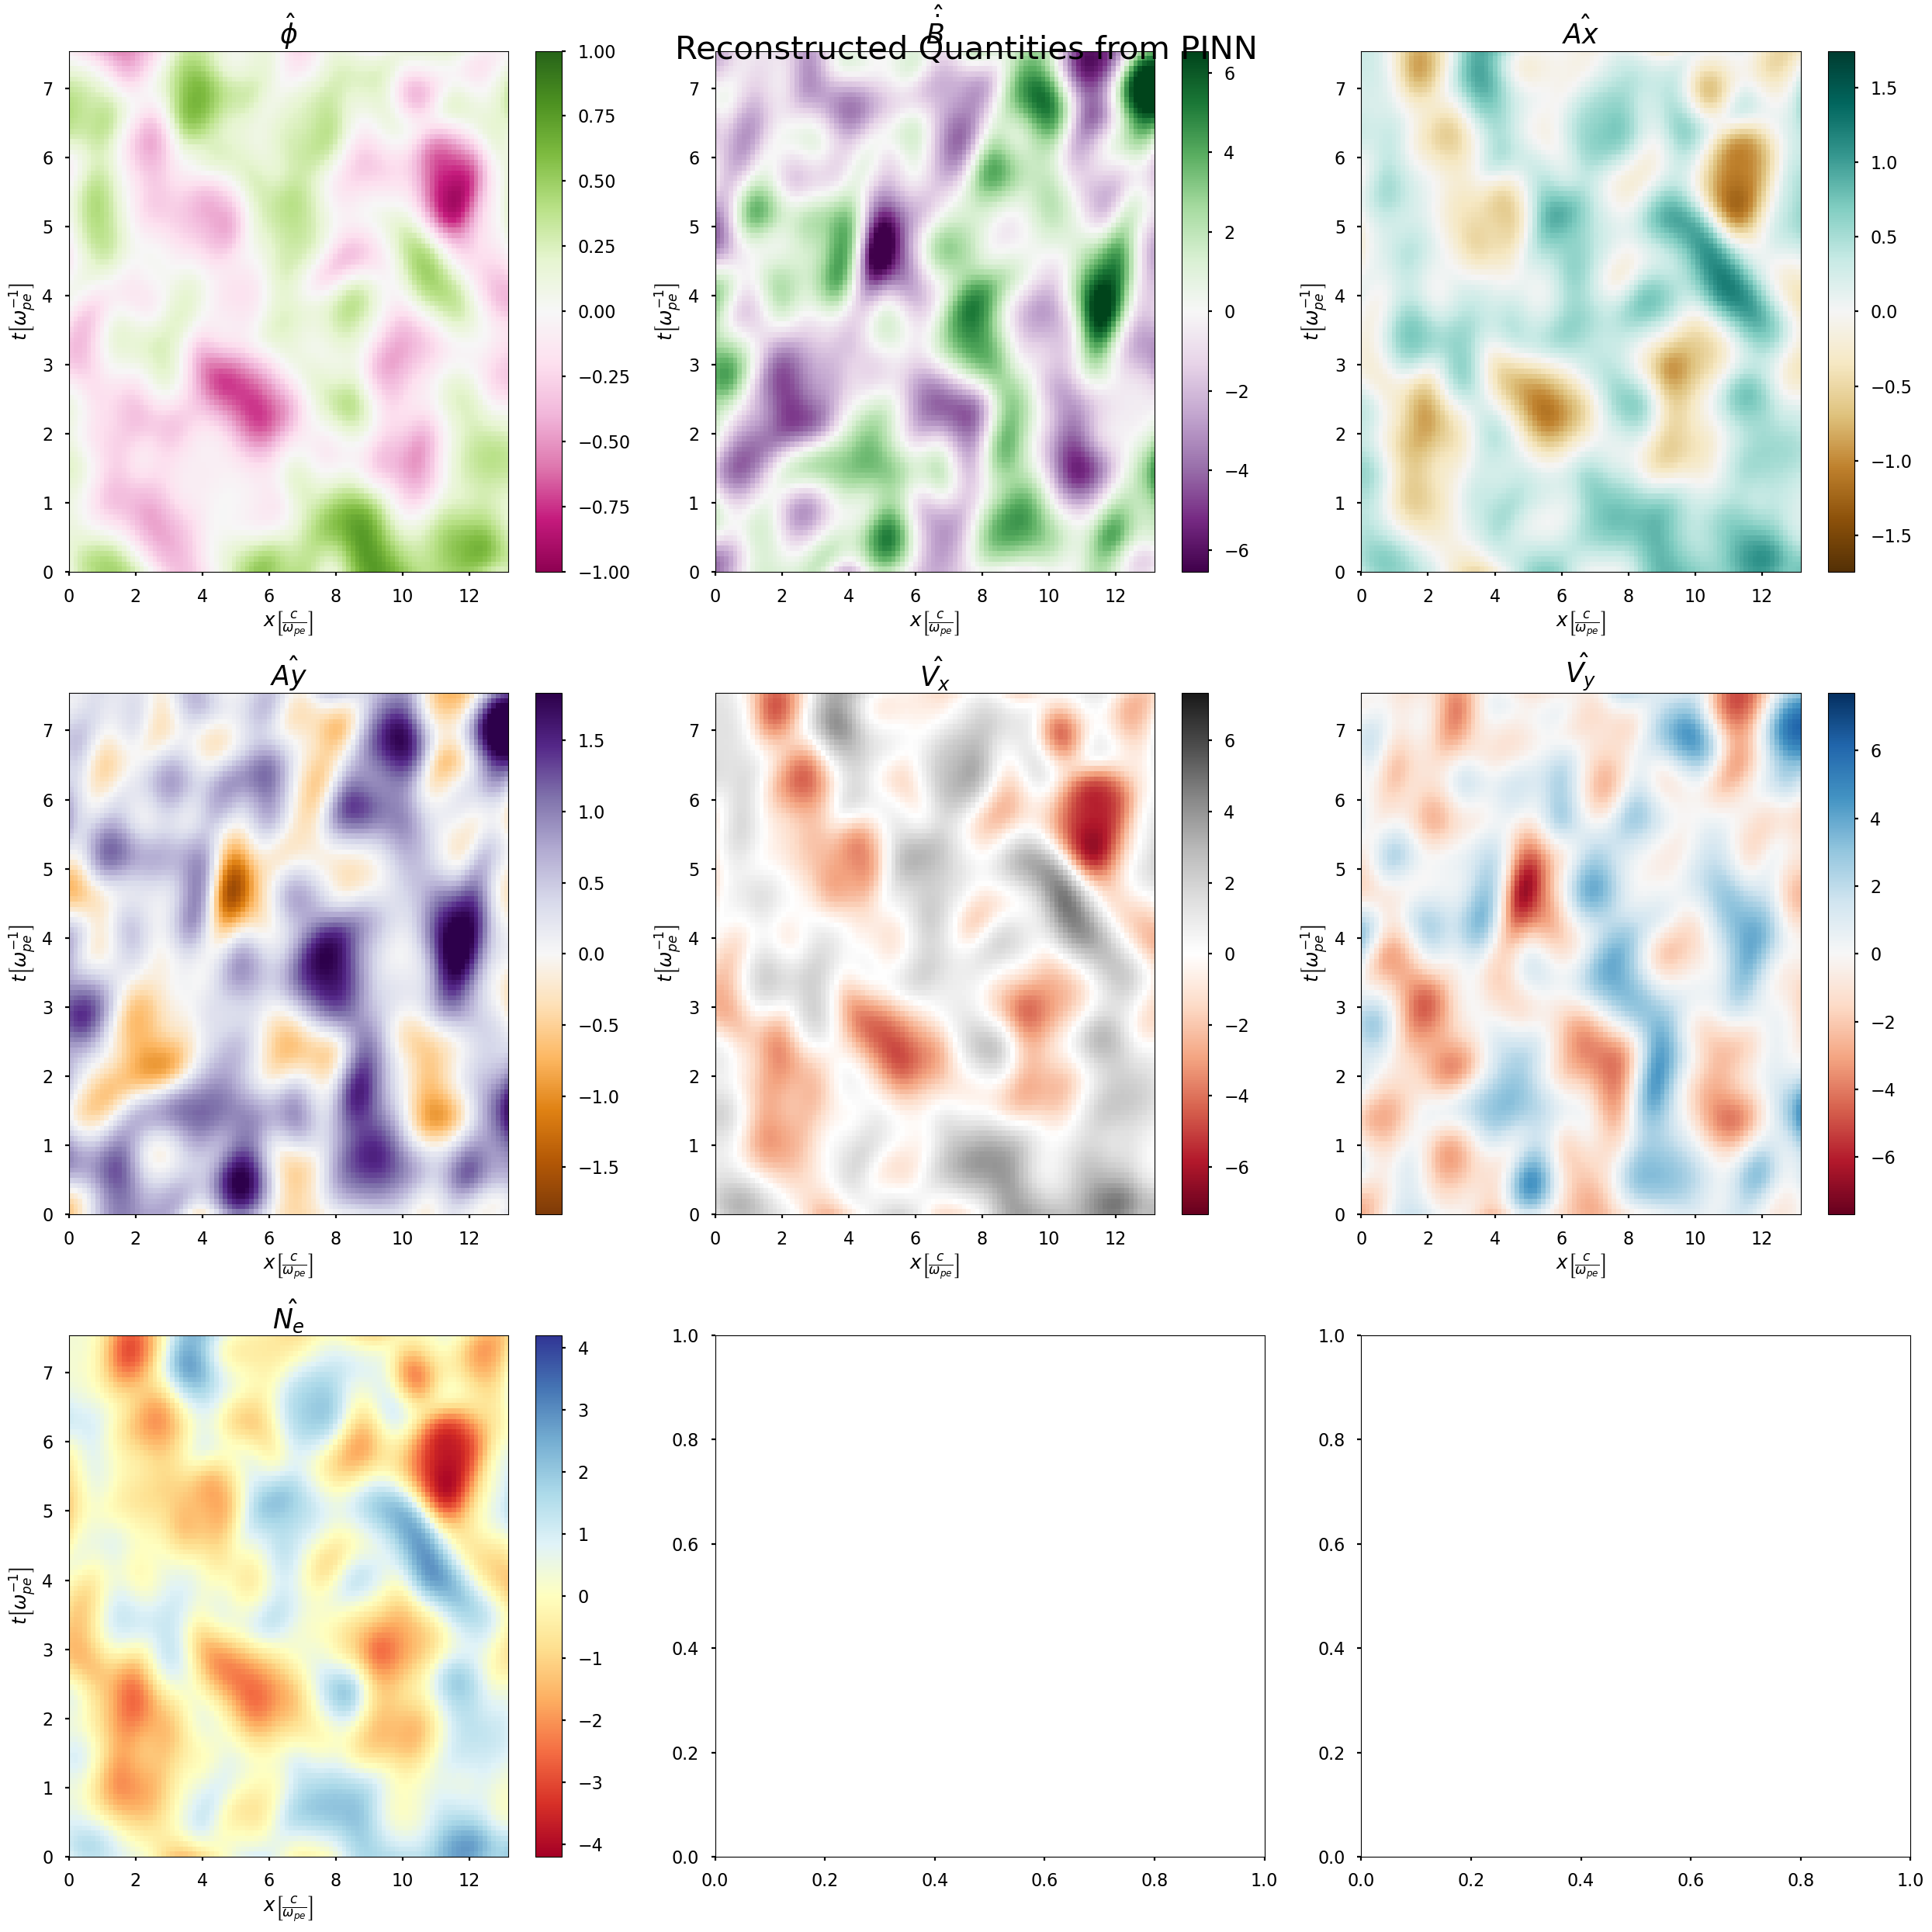

In [16]:
x_flat, t_flat, phi_flat, Bdot_flat, Ax_flat, Ay_flat, Vx_flat, Vy_flat, N_flat, B0_flat = generate_data(
                            xmin=xmin_init, xmax=xmax_init, tmin=tmin_init, tmax=tmax_init, nx=100, nt=100, vth=vth,
                            omega_ce=omega_ce, omega_pe=omega_pe, omega_list=[2.5], phi_amp_list=[1.0],
                            delta_list=[0.0])
ground_truth = np.real(np.array([phi_flat, Bdot_flat, Ax_flat, Ay_flat, Vx_flat, Vy_flat, N_flat]))

means_np = np.mean(ground_truth, axis=1)
stds_np = np.std(ground_truth, axis=1) + 1e-8
means_tensor = torch.tensor(means_np, dtype=torch.float32).reshape(1, 7)
stds_tensor = torch.tensor(stds_np, dtype=torch.float32).reshape(1, 7)

plot_reconstructed_quantities(device = model_params['device'],
                                  model=model,
                                  extent=model_params['extent'],
                                  quantities_GT=ground_truth,
                                  Nt=100,
                                  Nx=100,
                                  means=means_tensor,
                                  stds=stds_tensor)

ValueError: operands could not be broadcast together with shapes (100,100) (10000,) 

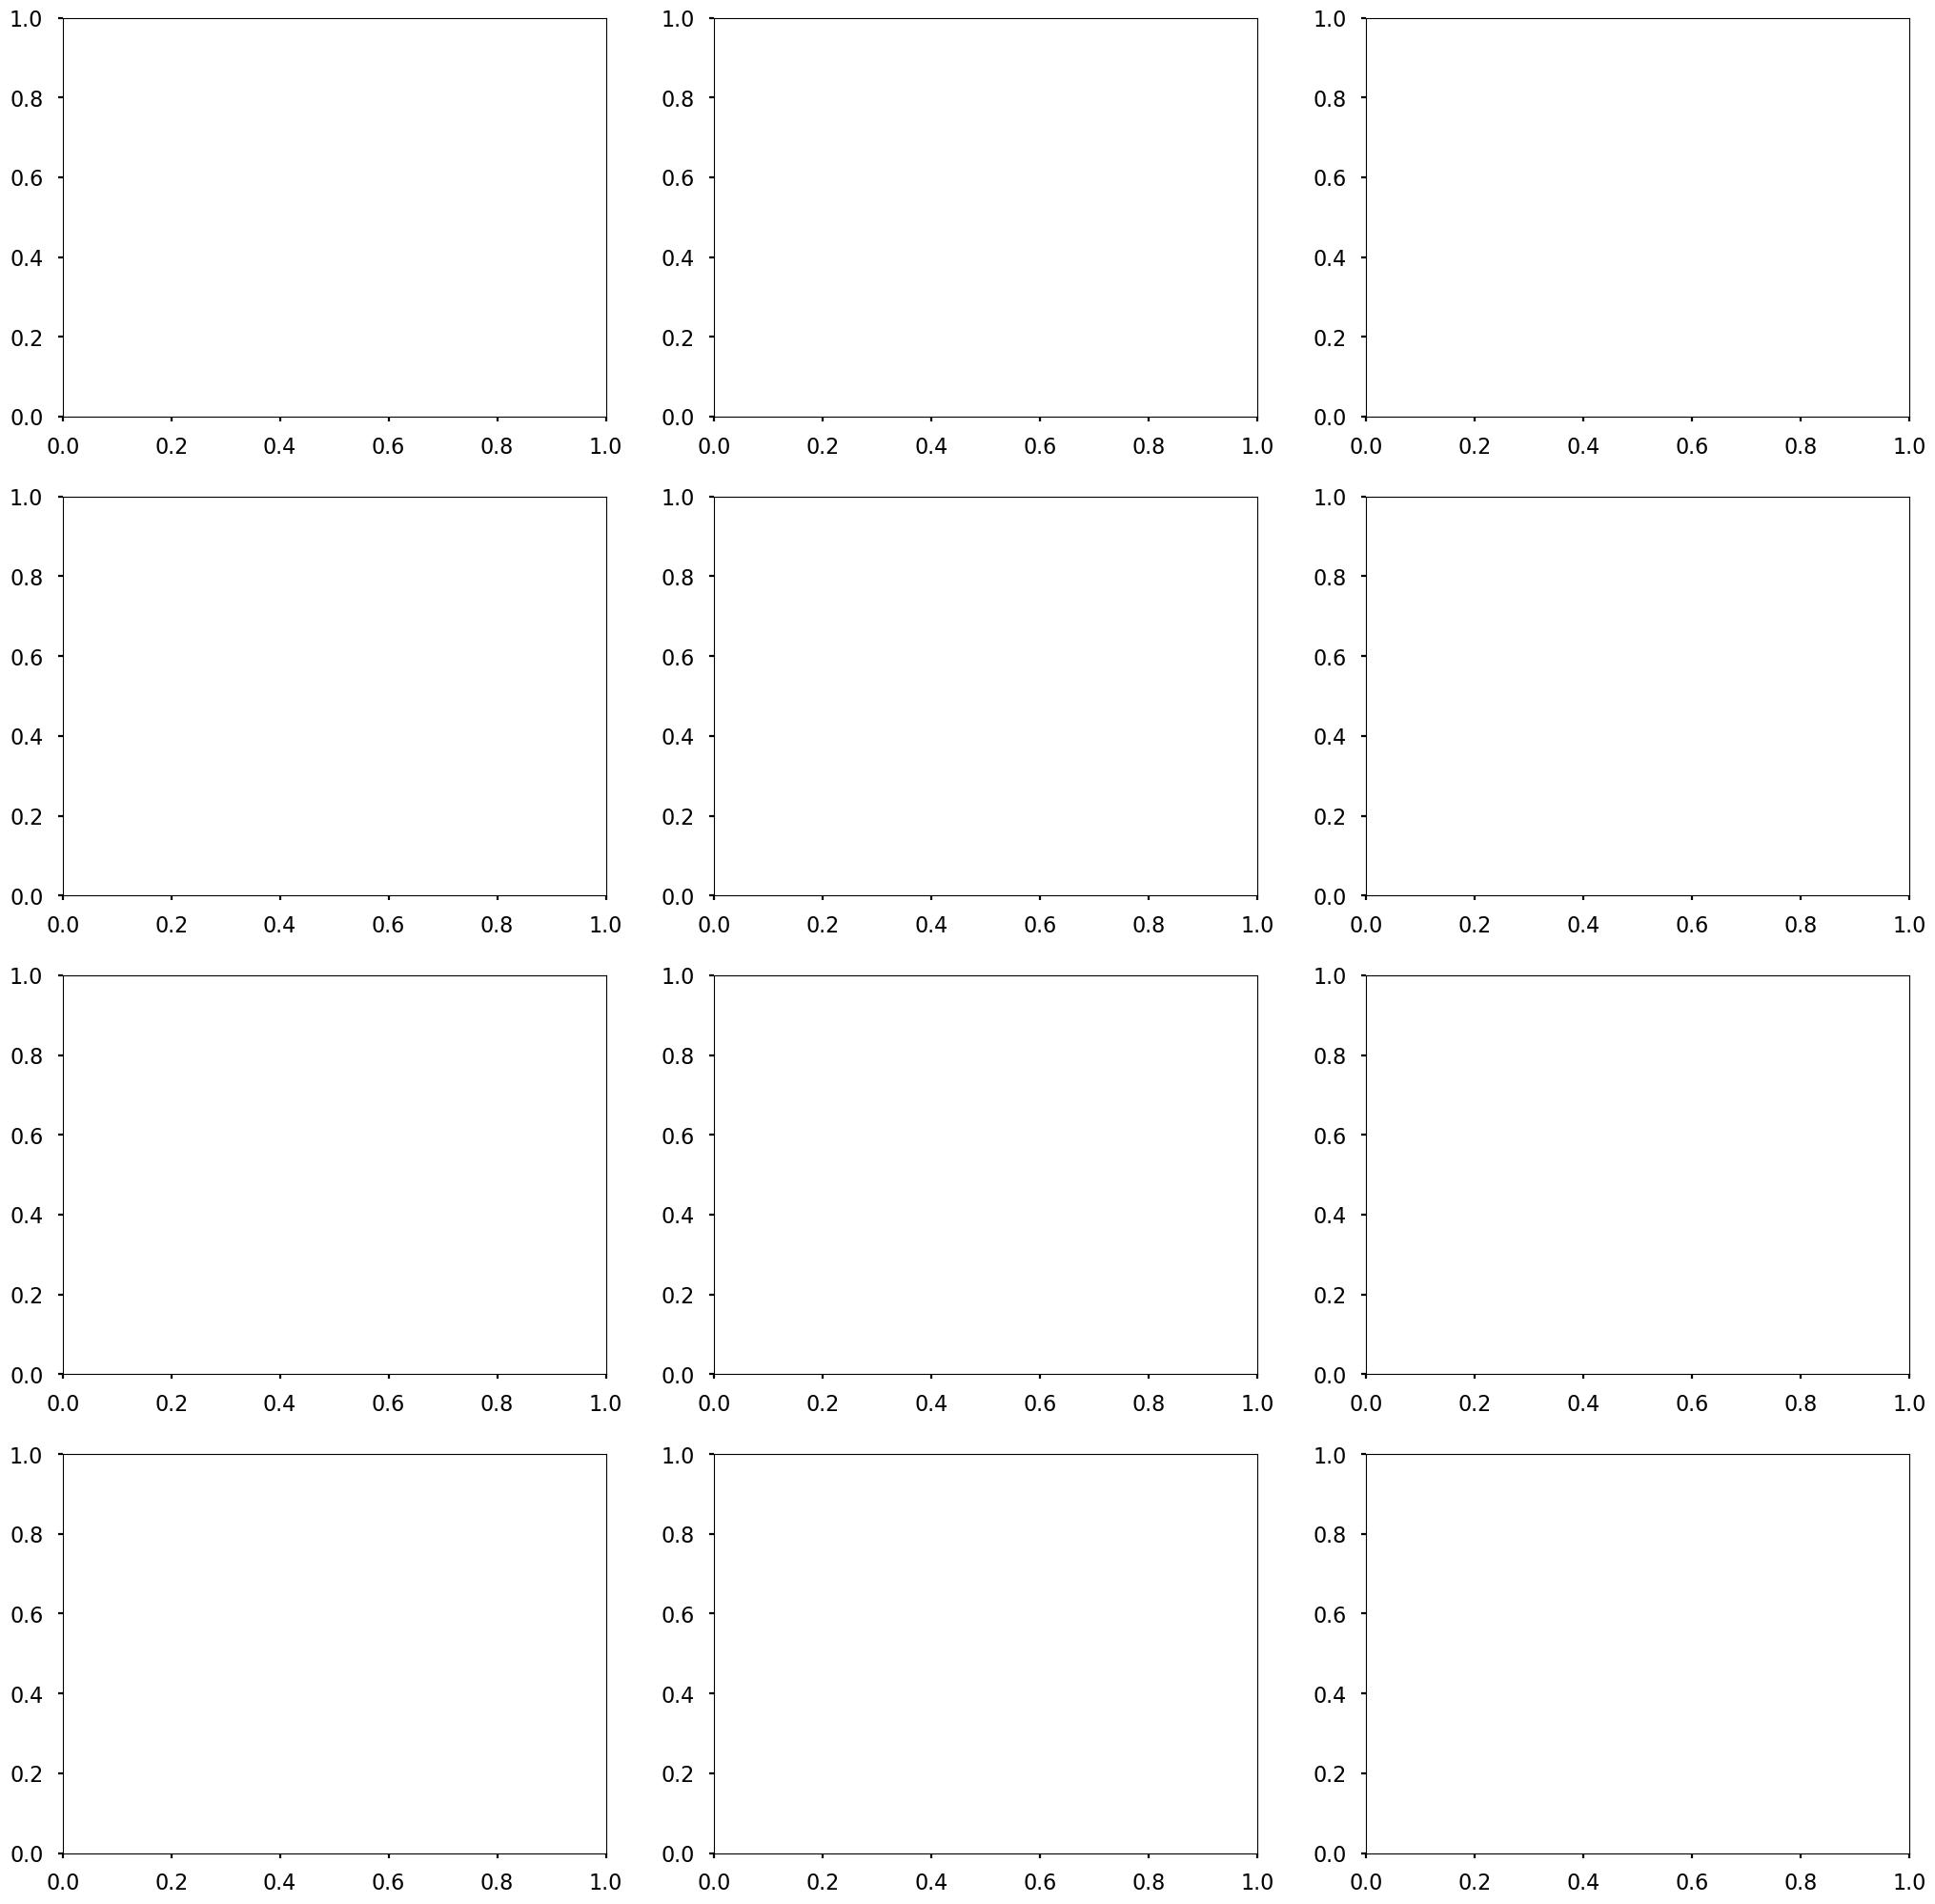

In [12]:
plot_reconstructed_quantities_errors(device = model_params['device'],
                                  model=model,
                                  extent=model_params['extent'],
                                  Nt=100,
                                  Nx=100,
                                  means=means_tensor,
                                  stds=stds_tensor,
                                  ground_truths=ground_truth)